# **Importação de Bibliotecas e Carregamento dos Dados**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import zscore
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("Bitext_Sample_Customer_Service_Training_Dataset.csv")

# Mantém apenas a variável textual e a variável-alvo
df = df[["utterance", "intent"]]

def print_formatado(*args, prefixo=5, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * 100)
    print(titulo)
    print("=" * 100)

# **Inspeção Inicial**

In [ ]:
print_formatado("1. Tamanho do dataset:")
print(df.shape)

print_formatado("2. Variáveis do dataset:")
print(df.columns)

print_formatado("3. Significado das colunas:")
print("Ver Markdown")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização dos registros:")
df.info()
print("Ver Markdown")

print_formatado("6. Exemplo de valores:")

print("\nPrimeiros registros:")
print(df.head())

print("\nÚltimos registros:")
print(df.tail())

print("\nRegistros aleatórios:")
print(df.sample(5, random_state=1))

print("\nExemplo dataset:")
display(df)

print_formatado("7. Identificação das variáveis")

print("\nVariável textual:")
print("utterance")

print("\nVariável-alvo:")
print("intent")

print(f"\nNúmero de textos distintos: {df['utterance'].nunique()}")
print(f"Número de classes da variável-alvo: {df['intent'].nunique()}")

print("\nClasses da variável-alvo:")
print(df["intent"].unique())

print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown")

print_formatado("9. Possíveis problemas nos dados")
print("Ver Markdown")



1. Tamanho do dataset:
(6539, 2)


2. Variáveis do dataset:
Index(['utterance', 'intent'], dtype='object')


3. Significado das colunas:
Ver Markdown


4. Tipos dos dados:
utterance    object
intent       object
dtype: object


5. Organização dos registros:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6539 entries, 0 to 6538
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   utterance  6539 non-null   object
 1   intent     6539 non-null   object
dtypes: object(2)
memory usage: 102.3+ KB
Ver Markdown


6. Exemplo de valores:

Primeiros registros:
                                           utterance        intent
0   would it be possible to cancel the order I made?  cancel_order
1                                   cancelling order  cancel_order
2  I need assistance canceling the last order I h...  cancel_order
3            problem with canceling the order I made  cancel_order
4        I don't know how to cancel the o

,utterance,intent
0,would it be possible to cancel the order I made?,cancel_order
1,cancelling order,cancel_order
2,I need assistance canceling the last order I h...,cancel_order
3,problem with canceling the order I made,cancel_order
4,I don't know how to cancel the order I made,cancel_order
...,...,...
6534,I do not know what I have to do to track the r...,track_refund
6535,check refund status,track_refund
6536,help me check the refund status,track_refund
6537,how can I check if there is any updates on my ...,track_refund




7. Identificação das variáveis

Variável textual:
utterance

Variável-alvo:
intent

Número de textos distintos: 6539
Número de classes da variável-alvo: 27

Classes da variável-alvo:
['cancel_order' 'change_order' 'change_shipping_address'
 'check_cancellation_fee' 'check_invoice' 'check_payment_methods'
 'check_refund_policy' 'complaint' 'contact_customer_service'
 'contact_human_agent' 'create_account' 'delete_account'
 'delivery_options' 'delivery_period' 'edit_account' 'get_invoice'
 'get_refund' 'newsletter_subscription' 'payment_issue' 'place_order'
 'recover_password' 'registration_problems' 'review'
 'set_up_shipping_address' 'switch_account' 'track_order' 'track_refund']


8. Variáveis relevantes para o objetivo da análise
Ver Markdown


9. Possíveis problemas nos dados
Ver Markdown


### 3. Significado das colunas

- **`utterance`**: mensagem textual enviada pelo cliente ao serviço de atendimento. É a principal variável de entrada do problema e contém linguagem natural livre, como `cancelling order` ou `help me to talk to an agent`.
- **`intent`**: intenção associada à mensagem do cliente. É a **variável-alvo** do problema de classificação. Exemplos incluem `cancel_order`, `track_order`, `get_refund` e `contact_human_agent`.

As demais colunas existentes no dataset original (`category` e `tags`) não serão consideradas nesta análise inicial, pois o objetivo é concentrar o EDA na variável textual e em sua respectiva classe.

---

### 5. Organização dos Registros

- Considerando apenas `utterance` e `intent`, o dataset possui **6.539 registros e 2 colunas**.
- Nenhuma das duas variáveis apresenta valores nulos detectados pelo Pandas.
- Ambas foram carregadas como `object`, o que é esperado para variáveis contendo strings.
- Os registros **não estão embaralhados aleatoriamente**. Eles estão agrupados pela variável `intent`.
- As diferentes classes aparecem em blocos consecutivos no dataset.

Esse último ponto é importante caso posteriormente seja feita uma separação entre conjuntos de treino e teste, pois não seria adequado simplesmente utilizar as primeiras linhas para treino e as últimas para teste.

---

### 6. Exemplo de valores

Alguns exemplos encontrados no dataset são:

| utterance | intent |
|---|---|
| `would it be possible to cancel the order I made?` | `cancel_order` |
| `cancelling order` | `cancel_order` |
| `help me to talk to an agent` | `contact_human_agent` |
| `I need help checking the status of my refund` | `track_refund` |
| `can I check your money back policy?` | `check_refund_policy` |

Os exemplos mostram que `utterance` contém frases em linguagem natural de diferentes tamanhos e formas de expressão, enquanto `intent` fornece a classe correspondente.

---

### 7. Identificação das variáveis

- **Variável textual:** `utterance`
- **Variável-alvo categórica:** `intent`

O dataset possui diversas classes distintas de `intent`, representando diferentes tipos de solicitação realizadas pelos clientes.

Algumas das classes encontradas são:

- `cancel_order`
- `change_order`
- `change_shipping_address`
- `check_cancellation_fee`
- `check_invoice`
- `check_payment_methods`
- `check_refund_policy`
- `complaint`
- `contact_customer_service`
- `contact_human_agent`
- `create_account`
- `delete_account`
- `delivery_options`
- `delivery_period`
- `edit_account`
- `get_invoice`
- `get_refund`
- `newsletter_subscription`
- `payment_issue`
- `place_order`
- `recover_password`
- `registration_problems`
- `review`
- `set_up_shipping_address`
- `switch_account`
- `track_order`
- `track_refund`

---

### 8. Variáveis relevantes para o objetivo da análise

A variável **`utterance`** é a principal variável explicativa, pois contém o texto a partir do qual será identificada a intenção do cliente.

A variável **`intent`** é a variável-alvo, representando a classe que um modelo de classificação deverá prever.

O problema pode ser representado de forma simplificada como:

`utterance` → **modelo de classificação de texto** → `intent`

Por exemplo:

`"where is my order?"` → **modelo** → `track_order`

Dessa forma, a análise exploratória deve se concentrar principalmente nas características dos textos presentes em `utterance` e em sua relação com as diferentes classes de `intent`.

---

### 9. Possíveis problemas nos dados

Nesta inspeção inicial, não foram encontrados valores nulos nas variáveis analisadas. Entretanto, alguns aspectos devem ser investigados nas próximas etapas do EDA textual:

- possíveis diferenças na quantidade de exemplos entre as classes de `intent`;
- distribuição do tamanho dos textos;
- presença de textos muito curtos ou muito longos;
- presença de textos duplicados;
- uso de pontuação e caracteres especiais;
- diferenças de vocabulário entre as classes;
- palavras muito frequentes e pouco informativas;
- similaridade textual entre intenções diferentes;
- necessidade de normalização dos textos.

Esses aspectos serão analisados nas próximas etapas do EDA, com foco específico nas características da variável textual `utterance`.

# **Verificação da Qualidade dos Dados**

In [ ]:
import unicodedata

coluna_texto = "utterance"
coluna_alvo = "intent"
colunas_analisadas = [coluna_texto, coluna_alvo]

print_formatado("1. Valores ausentes:")

print("Valores ausentes (NaN):")
print(df[colunas_analisadas].isnull().sum())

print("\nValores vazios:")
for coluna in colunas_analisadas:
    qtd_vazios = (
        df[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    print(f"{coluna:<15}: {qtd_vazios}")

print("Ver Markdown")


print_formatado("2. Registros duplicados:")

print("Duplicatas completas:")
print(df[colunas_analisadas].duplicated().sum())

print("\nDuplicadas considerando apenas utterance:")
print(df[coluna_texto].duplicated().sum())

print("Ver Markdown")


print_formatado("3. Tipos de Dados:")

for coluna in colunas_analisadas:
    print(f"\n{coluna}:")
    print(df[coluna].apply(type).value_counts())

print("\nQuantidade de valores únicos:")
for coluna in colunas_analisadas:
    print(f"{coluna:<15}: {df[coluna].nunique()}")

print("\nDistribuição absoluta da variável-alvo:")
print(df[coluna_alvo].value_counts())

print("Ver Markdown")


print_formatado("4. Valores escritos de maneira diferente:")

def normalizar_texto(valor):
    if pd.isna(valor):
        return valor

    valor = valor.strip().lower()

    valor = (
        unicodedata.normalize("NFKD", valor)
        .encode("ASCII", "ignore")
        .decode("utf-8")
    )

    valor = " ".join(valor.split())

    return valor


for coluna in colunas_analisadas:
    com_normalizacao = df[coluna].apply(normalizar_texto).nunique()
    sem_normalizacao = df[coluna].nunique()

    print(
        f"{coluna:<15} -> "
        f"Com Normalização: {com_normalizacao} | "
        f"Sem Normalização: {sem_normalizacao}"
    )


print_formatado("5. Textos vazios ou espaços extras:")

for coluna in colunas_analisadas:
    qtd_espacos_extremos = (
        df[coluna].fillna("").astype(str)
        != df[coluna].fillna("").astype(str).str.strip()
    ).sum()

    print(f"{coluna:<15} - espaços no início/final: {qtd_espacos_extremos}")

print("\nEspaços consecutivos no interior do texto:")

for coluna in colunas_analisadas:
    qtd_espacos_internos = (
        df[coluna]
        .fillna("")
        .astype(str)
        .str.contains(r"\s{2,}", regex=True)
        .sum()
    )

    print(f"{coluna:<15}: {qtd_espacos_internos}")


print_formatado("6. Valores impossíveis ou fora do contexto:")

print("\nUtterances sem caracteres alfanuméricos:")
somente_simbolos = (
    df[coluna_texto]
    .fillna("")
    .astype(str)
    .str.fullmatch(r"\s*[^A-Za-z0-9]+\s*", na=False)
)
print(somente_simbolos.sum())

print("\nUtterances com quebra de linha:")
print(
    df[coluna_texto]
    .fillna("")
    .astype(str)
    .str.contains("\n", regex=False)
    .sum()
)

print("\nUtterances contendo placeholders entre chaves:")
print(
    df[coluna_texto]
    .fillna("")
    .astype(str)
    .str.contains(r"\{[^{}]+\}", regex=True)
    .sum()
)

print("\nCategorias de intent com caracteres inesperados:")
padrao = r"[^a-z_]"

valores_estranhos = df[
    df[coluna_alvo]
    .fillna("")
    .astype(str)
    .str.contains(padrao, regex=True)
][coluna_alvo].unique()

if len(valores_estranhos) > 0:
    print(valores_estranhos)
else:
    print("Nenhum caractere inesperado.")

print("\nConsistência entre utterance e intent:")

mapeamento = df.groupby(coluna_texto)[coluna_alvo].nunique()
inconsistentes = mapeamento[mapeamento > 1]

if len(inconsistentes) > 0:
    print(inconsistentes)
else:
    print("Nenhuma utterance associada a mais de uma intent.")

print_formatado("7. Valores únicos de intent")
print(df['intent'].unique())



1. Valores ausentes:
Valores ausentes (NaN):
utterance    0
intent       0
dtype: int64

Valores vazios:
utterance      : 0
intent         : 0
Ver Markdown


2. Registros duplicados:
Duplicatas completas:
0

Duplicadas considerando apenas utterance:
0
Ver Markdown


3. Tipos de Dados:

utterance:
utterance
<class 'str'>    6539
Name: count, dtype: int64

intent:
intent
<class 'str'>    6539
Name: count, dtype: int64

Quantidade de valores únicos:
utterance      : 6539
intent         : 27

Distribuição absoluta da variável-alvo:
intent
get_invoice                 268
payment_issue               263
check_invoice               258
contact_customer_service    253
complaint                   252
review                      248
check_payment_methods       246
set_up_shipping_address     246
check_cancellation_fee      246
cancel_order                246
track_order                 245
place_order                 243
check_refund_policy         240
get_refund                  239
registrat

## **Observações Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade
* ***Não há valores ausentes (`NaN`) ou valores vazios nas variáveis `utterance` e `intent`.***
    * ***Não é necessário realizar tratamento de valores ausentes.***

### 2. Registros duplicados
* ***Não há registros duplicados considerando conjuntamente `utterance` e `intent`.***
* ***Também não há valores de `utterance` exatamente duplicados.***
    * ***Após normalização de letras maiúsculas/minúsculas e espaços, são identificadas algumas mensagens equivalentes. Essas ocorrências devem ser consideradas durante a preparação dos textos.***

### 3. Tipos dos dados estão corretos
* ***As variáveis `utterance` e `intent` foram carregadas como `object`, pois possuem conteúdo textual.***
    * ***Manter `utterance` como variável textual e converter `intent` para o tipo `category` na etapa de preparação dos dados.***

### Outras observações:
* Não há espaços extras no início ou no final dos valores de `utterance` e `intent`.
* Há algumas `utterance` com espaços consecutivos no interior das frases.
* Não há textos formados apenas por símbolos.
* Não há quebras de linha ou placeholders entre chaves em `utterance`.
* Não há inconsistências de capitalização ou caracteres inesperados nas categorias de `intent`.
* Cada `utterance` está associada a apenas uma categoria de `intent`, não havendo conflito entre o texto e a variável-alvo.
* As pequenas diferenças encontradas após a normalização de `utterance` estão relacionadas principalmente à capitalização e à quantidade de espaços, podendo ser corrigidas na etapa de limpeza e preparação dos dados.

# **Limpeza e Preparação dos Dados**

In [ ]:
# # Mantém apenas a variável textual e a variável-alvo
# df = df[["utterance", "intent"]].copy()


# print_formatado("1. Remover/tratar registros duplicados desnecessários;")

# print("\nRemover duplicadas completas:")

# print(f"Duplicatas completas antes: {df.duplicated().sum()}")

# df = df.drop_duplicates()

# print(f"\nDuplicatas completas depois: {df.duplicated().sum()}")


# print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada")

# print("Quantidade de valores ausentes:")
# print(df[["utterance", "intent"]].isnull().sum())

# print("\nQuantidade de valores vazios:")

# for coluna in ["utterance", "intent"]:
#     quantidade = (
#         df[coluna]
#         .fillna("")
#         .astype(str)
#         .str.strip()
#         .eq("")
#         .sum()
#     )

#     print(f"{coluna:<15}: {quantidade}")


# print_formatado("3. Corrigir tipos das colunas:")

# print("Tipos antes da conversão:")
# print(df[["utterance", "intent"]].dtypes)

# df["utterance"] = df["utterance"].astype("string")
# df["intent"] = df["intent"].astype("category")

# print("\nTipos depois da conversão:")
# print(df[["utterance", "intent"]].dtypes)


# print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;")

# # Remove espaços no início e final e substitui
# # sequências de espaços por um único espaço
# df["utterance"] = (
#     df["utterance"]
#     .str.replace(r"\s+", " ", regex=True)
#     .str.strip()
# )

# # Padroniza a variável-alvo
# df["intent"] = (
#     df["intent"]
#     .astype("string")
#     .str.strip()
#     .str.lower()
#     .astype("category")
# )

# print("Textos com espaços consecutivos após o tratamento:")
# print(
#     df["utterance"]
#     .str.contains(r"\s{2,}", regex=True)
#     .sum()
# )

# # A limpeza dos espaços pode fazer dois registros diferentes
# # se tornarem exatamente iguais
# print("\nDuplicatas após correção dos espaços:")
# print(df.duplicated().sum())

# df = df.drop_duplicates().reset_index(drop=True)

# print("\nDuplicatas depois do tratamento:")
# print(df.duplicated().sum())

# print("Ver Markdown")


# print_formatado("5. Corrigir valores inválidos;")

# utterance_invalida = (
#     df["utterance"]
#     .fillna("")
#     .str.strip()
#     .eq("")
#     .sum()
# )

# intent_invalida = (
#     df["intent"]
#     .astype("string")
#     .fillna("")
#     .str.strip()
#     .eq("")
#     .sum()
# )

# print(f"Utterances inválidas: {utterance_invalida}")
# print(f"Intents inválidas: {intent_invalida}")

# print("Ver Markdown")


# print_formatado("6. Criar variáveis numéricas derivadas do texto;")

# # Quantidade de palavras da utterance
# df["qtd_palavras"] = (
#     df["utterance"]
#     .str.split()
#     .str.len()
# )

# # Tamanho da frase em quantidade de caracteres
# df["tamanho_frase"] = (
#     df["utterance"]
#     .str.len()
# )

# print(df[["utterance", "intent", "qtd_palavras", "tamanho_frase"]].head())

# print("\nTipos das novas variáveis:")
# print(df[["qtd_palavras", "tamanho_frase"]].dtypes)
from sklearn.feature_extraction.text import CountVectorizer


# Mantém apenas a variável textual e a variável-alvo
df = df[["utterance", "intent"]].copy()


print_formatado("1. Remover/tratar registros duplicados desnecessários;")

print("\nRemover duplicadas completas:")

print(f"Duplicatas completas antes: {df.duplicated().sum()}")

df = df.drop_duplicates()

print(f"\nDuplicatas completas depois: {df.duplicated().sum()}")


print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada")

print("Quantidade de valores ausentes:")
print(df[["utterance", "intent"]].isnull().sum())

print("\nQuantidade de valores vazios:")

for coluna in ["utterance", "intent"]:
    quantidade = (
        df[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{coluna:<15}: {quantidade}")


print_formatado("3. Corrigir tipos das colunas:")

print("Tipos antes da conversão:")
print(df[["utterance", "intent"]].dtypes)

df["utterance"] = df["utterance"].astype("string")
df["intent"] = df["intent"].astype("category")

print("\nTipos depois da conversão:")
print(df[["utterance", "intent"]].dtypes)


print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;")

# Remove espaços no início e final e substitui
# sequências de espaços por um único espaço
df["utterance"] = (
    df["utterance"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Padroniza a variável-alvo
df["intent"] = (
    df["intent"]
    .astype("string")
    .str.strip()
    .str.lower()
    .astype("category")
)

print("Textos com espaços consecutivos após o tratamento:")
print(
    df["utterance"]
    .str.contains(r"\s{2,}", regex=True)
    .sum()
)

print("\nDuplicatas após correção dos espaços:")
print(df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicatas depois do tratamento:")
print(df.duplicated().sum())

print("Ver Markdown")


print_formatado("5. Corrigir valores inválidos;")

utterance_invalida = (
    df["utterance"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

intent_invalida = (
    df["intent"]
    .astype("string")
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(f"Utterances inválidas: {utterance_invalida}")
print(f"Intents inválidas: {intent_invalida}")

print("Ver Markdown")

print_formatado("6. Remover caracteres de pontuação;")

# Remove caracteres de pontuação da variável utterance
df["utterance"] = (
    df["utterance"]
    .str.replace(r"[^\w\s]", "", regex=True)
)

print(df["utterance"].head())

print("Ver Markdown")


print_formatado("7. Contagem de número de palavras e tamanho do texto")

# Quantidade de palavras da utterance
df["qtd_palavras"] = (
    df["utterance"]
    .str.split()
    .str.len()
)

# Tamanho da frase em quantidade de caracteres
df["tamanho_frase"] = (
    df["utterance"]
    .str.len()
)

print(
    df[
        ["utterance", "intent", "qtd_palavras", "tamanho_frase"]
    ].head()
)

print("\nTipos das novas variáveis:")
print(df[["qtd_palavras", "tamanho_frase"]].dtypes)


print_formatado("8. Vetorização de contagem de palavras (CountVectorizer);")

vectorizer = CountVectorizer(stop_words='english')

X_vetorizado = vectorizer.fit_transform(df["utterance"])

vocabulario = vectorizer.get_feature_names_out()

print("Dimensão da matriz de contagem:")
print(X_vetorizado.shape)

print("\nQuantidade de palavras no vocabulário:")
print(len(vocabulario))

print("\nExemplo de palavras do vocabulário:")
print(vocabulario[:20])

print("\nRepresentação vetorizada da primeira utterance:")
print(X_vetorizado[0])

print("\nPrimeira utterance:")
print(df["utterance"].iloc[0])



1. Remover/tratar registros duplicados desnecessários;

Remover duplicadas completas:
Duplicatas completas antes: 0

Duplicatas completas depois: 0


2. Remover/tratar valores ausentes tratados de forma justificada
Quantidade de valores ausentes:
utterance    0
intent       0
dtype: int64

Quantidade de valores vazios:
utterance      : 0
intent         : 0


3. Corrigir tipos das colunas:
Tipos antes da conversão:
utterance    object
intent       object
dtype: object

Tipos depois da conversão:
utterance    string[python]
intent             category
dtype: object


4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;
Textos com espaços consecutivos após o tratamento:
0

Duplicatas após correção dos espaços:
1

Duplicatas depois do tratamento:
0
Ver Markdown


5. Corrigir valores inválidos;
Utterances inválidas: 0
Intents inválidas: 0
Ver Markdown


6. Remover caracteres de pontuação;
0      would it be possible to cancel the order I made
1                         

## **Observações Limpeza e Preparação dos Dados**

### 1. Remover/tratar registros duplicados desnecessários

* Não foram encontradas duplicatas completas inicialmente.
* Após a padronização dos espaços da variável `utterance`, foi identificado **1 registro duplicado**.
* Essa duplicata foi removida.

  * Após o tratamento, o dataset passou a não apresentar registros duplicados.

### 2. Remover/tratar valores ausentes de forma justificada

* Não foram encontrados valores ausentes (`NaN`) nas variáveis `utterance` e `intent`.
* Também não foram encontrados valores vazios nessas duas variáveis.

  * Dessa forma, não foi necessário remover ou substituir registros devido à ausência de dados.

### 3. Corrigir tipos das colunas

* A variável `utterance` foi convertida de `object` para `string`, pois representa o conteúdo textual que será analisado.
* A variável `intent` foi convertida de `object` para `category`, pois representa a variável-alvo categórica do problema de classificação.

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes

* Foram removidos espaços existentes no início e no final das mensagens.
* Sequências de dois ou mais espaços consecutivos foram substituídas por um único espaço.
* Após o tratamento, não permaneceram textos com espaços consecutivos.
* A variável `intent` também foi padronizada, removendo espaços extras e convertendo seus valores para letras minúsculas.
* A normalização dos espaços fez com que dois registros anteriormente diferentes passassem a ser iguais, resultando em **1 duplicata**, que foi posteriormente removida.

### 5. Corrigir valores inválidos

* Não foram encontradas `utterance` inválidas ou vazias.
* Não foram encontradas categorias de `intent` inválidas ou vazias.

  * Portanto, não foi necessária a remoção de registros por valores inválidos.

### 6. Remover caracteres de pontuação

* Foram removidos caracteres de pontuação da variável `utterance`.
* Caracteres como pontos, vírgulas, interrogações, exclamações e apóstrofos foram desconsiderados.
* Essa etapa reduz variações desnecessárias entre palavras que possuem o mesmo significado textual.
* Por exemplo, termos como `order`, `order?` e `order!` passam a ser tratados da mesma maneira.
* A remoção da pontuação também prepara os textos para a etapa posterior de vetorização.

### 7. Contagem do número de palavras e tamanho do texto

Foram criadas duas novas variáveis numéricas derivadas de `utterance`:

#### `qtd_palavras`

* Representa a quantidade de palavras presentes em cada mensagem.
* Essa variável permite analisar o comprimento dos textos em termos de palavras.
* Pode ser utilizada posteriormente para identificar mensagens muito curtas, muito longas ou possíveis valores extremos.

#### `tamanho_frase`

* Representa a quantidade de caracteres presentes em cada mensagem.
* Essa variável complementa `qtd_palavras`, oferecendo outra medida do tamanho dos textos.
* As duas variáveis foram armazenadas como tipos numéricos inteiros.

Essas características permitem aplicar técnicas tradicionais de análise exploratória, como média, mediana, quartis, histogramas e boxplots, sobre propriedades originalmente derivadas de uma variável textual.

### 8. Vetorização de contagem de palavras (`CountVectorizer`)

* Foi utilizado o `CountVectorizer` para transformar a variável textual `utterance` em uma representação numérica baseada na frequência das palavras.
* Foram removidas automaticamente as **stopwords da língua inglesa**, por meio de `stop_words='english'`.

  * Dessa forma, palavras muito comuns, como `the`, `is`, `to` e `and`, não fazem parte da representação final.
* Após a vetorização, foi obtida uma matriz com dimensão **(6538, 556)**.

  * As **6538 linhas** representam as mensagens presentes no dataset após a limpeza e remoção de duplicatas.
  * As **556 colunas** representam os diferentes termos existentes no vocabulário após o pré-processamento e a remoção das stopwords.
* Portanto, o vocabulário utilizado pelo `CountVectorizer` possui **556 termos distintos**.
* Cada célula da matriz representa a quantidade de vezes que determinado termo aparece em determinada `utterance`.
* A matriz foi armazenada na variável `X_vetorizado`.

A representação vetorizada permite transformar os textos em dados numéricos que podem ser utilizados posteriormente tanto em análises exploratórias quanto em algoritmos de aprendizado de máquina.

### Observações adicionais sobre o vocabulário

* Entre os primeiros termos encontrados no vocabulário aparecem palavras como `account`, `access` e `accept`, mas também variações aparentemente incorretas, como `accdss`, `acconut`, `accouint` e `accoynt`.
* Isso indica a presença de **erros ortográficos e variações de escrita** nas mensagens do dataset.
* O `CountVectorizer` considera essas variações como palavras diferentes.
* Dessa forma, erros ortográficos podem aumentar artificialmente o tamanho do vocabulário e gerar características pouco frequentes.
* Esse comportamento deve ser considerado na análise exploratória das palavras mais e menos frequentes.

Após a etapa de limpeza e preparação, os dados passam a possuir três formas complementares de informação:

* **Texto original preparado:** `utterance`;
* **Variável-alvo:** `intent`;
* **Características numéricas do texto:** `qtd_palavras` e `tamanho_frase`;
* **Representação lexical:** matriz `X_vetorizado` gerada pelo `CountVectorizer`.




# **Análise Univariada**

### **Variáveis textuais**



1. Estatísticas tamanho do texto e quantidade palavras:

Tamanho do texto:
count       6538.0
mean     42.157541
std      10.558184
min            6.0
25%           35.0
50%           43.0
75%           51.0
max           60.0
Name: tamanho_frase, dtype: Float64

Quantidade de palavras:
count    6538.000000
mean        8.315540
std         2.401941
min         1.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        15.000000
Name: qtd_palavras, dtype: float64


2. Distribuição tamanho do texto e quantidade de palavras:


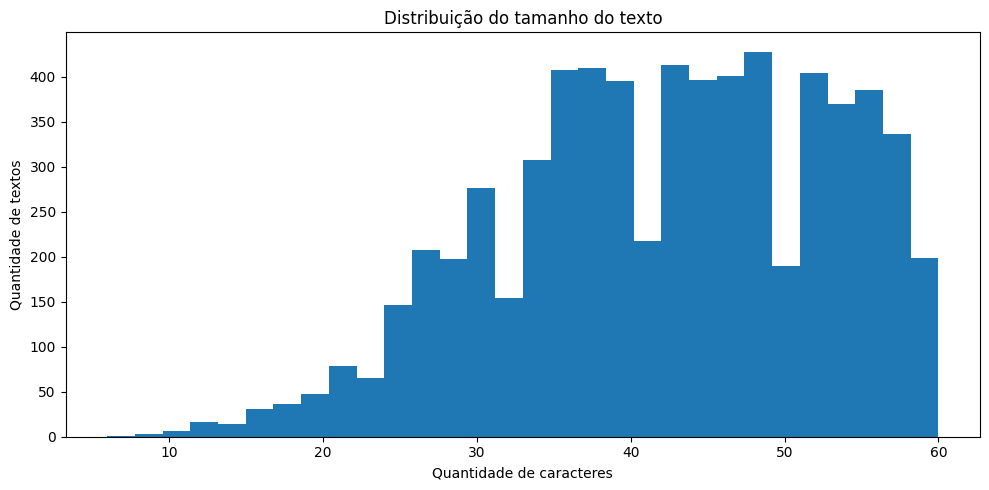

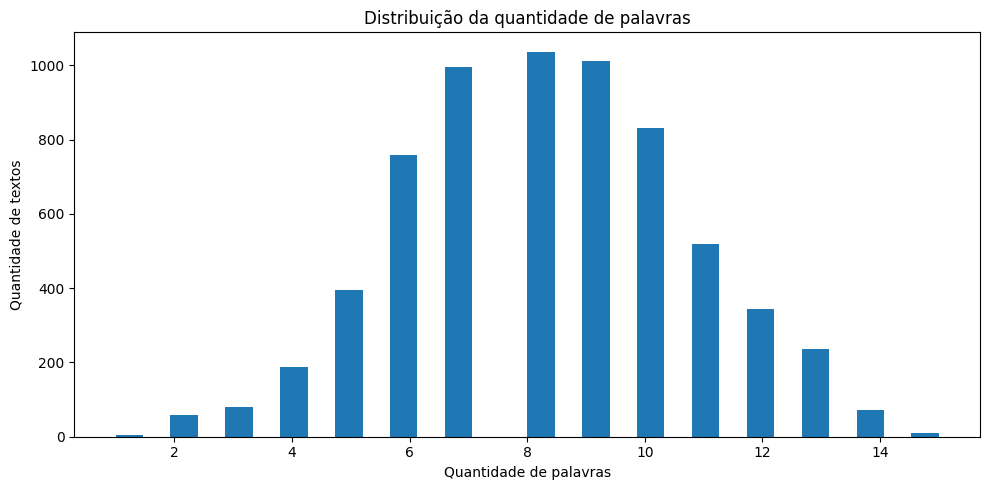



3. Palavras mais frequentes:
         palavra  frequencia
205         help        1676
95         check        1012
301         need         871
257         know         833
47    assistance         719
14       account         714
331        order         662
538         want         658
26       address         474
147     delivery         421
345      payment         411
437     shipping         410
391       refund         409
157         dont         390
228  information         315
330      options         293
135     customer         291
238     invoices         269
524         user         264
237      invoice         257


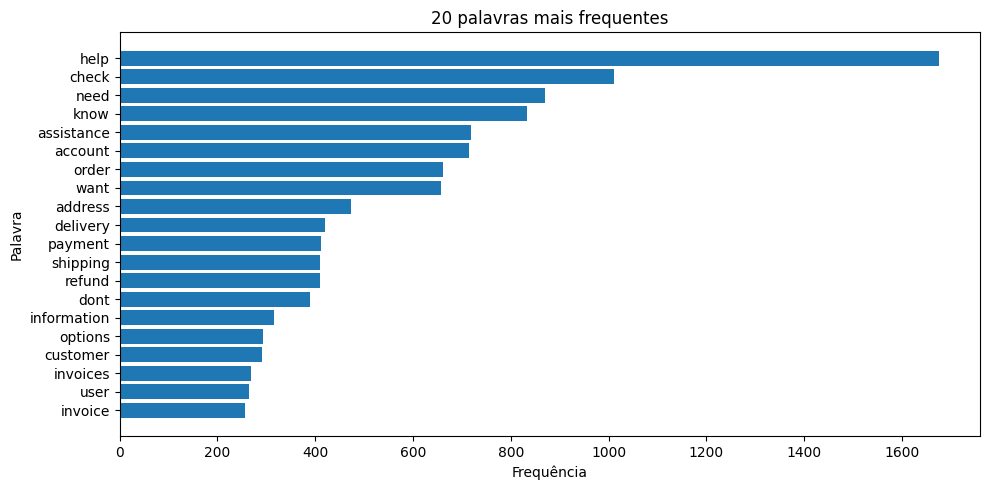

In [ ]:
print_formatado("1. Estatísticas tamanho do texto e quantidade palavras:")

print("\nTamanho do texto:")
print(df["tamanho_frase"].describe())

print("\nQuantidade de palavras:")
print(df["qtd_palavras"].describe())

print_formatado("2. Distribuição tamanho do texto e quantidade de palavras:")

plt.figure(figsize=(10, 5))

plt.hist(df["tamanho_frase"], bins=30)

plt.title("Distribuição do tamanho do texto")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Quantidade de textos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.hist(df["qtd_palavras"], bins=30)

plt.title("Distribuição da quantidade de palavras")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de textos")
plt.tight_layout()
plt.show()

print_formatado("3. Palavras mais frequentes:")

frequencia_palavras = X_vetorizado.sum(axis=0).A1

df_frequencia_palavras = pd.DataFrame({
    "palavra": vocabulario,
    "frequencia": frequencia_palavras
})

df_frequencia_palavras = (
    df_frequencia_palavras
    .sort_values("frequencia", ascending=False)
    .head(20)
)

print(df_frequencia_palavras)


plt.figure(figsize=(10, 5))

dados_plot = df_frequencia_palavras.sort_values("frequencia")

plt.barh(
    dados_plot["palavra"],
    dados_plot["frequencia"]
)

plt.title("20 palavras mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("Palavra")
plt.tight_layout()
plt.show()

### **Variáveis categóricas**



1. Quantidade de categorias:

Quantidade de categorias únicas por variável:
intent    27
dtype: int64


2. Frequência absoluta e relativa:

Frequência absoluta:

Variável 'intent':
intent
get_invoice                 268
payment_issue               263
check_invoice               258
contact_customer_service    253
complaint                   252
review                      248
cancel_order                246
set_up_shipping_address     246
check_payment_methods       246
check_cancellation_fee      245
track_order                 245
place_order                 243
check_refund_policy         240
get_refund                  239
registration_problems       239
track_refund                239
recover_password            239
newsletter_subscription     238
create_account              237
delivery_period             236
delete_account              236
delivery_options            236
edit_account                233
change_order                232
change_shipping_address     228
switch_acc

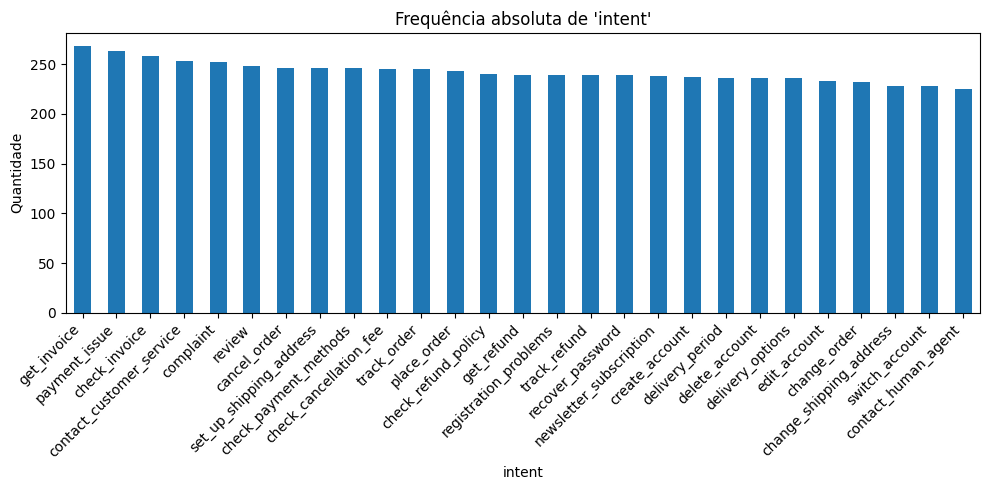


Frequência relativa:

Variável 'intent' (%):
intent
get_invoice                 4.10
payment_issue               4.02
check_invoice               3.95
contact_customer_service    3.87
complaint                   3.85
review                      3.79
cancel_order                3.76
set_up_shipping_address     3.76
check_payment_methods       3.76
check_cancellation_fee      3.75
track_order                 3.75
place_order                 3.72
check_refund_policy         3.67
get_refund                  3.66
registration_problems       3.66
track_refund                3.66
recover_password            3.66
newsletter_subscription     3.64
create_account              3.62
delivery_period             3.61
delete_account              3.61
delivery_options            3.61
edit_account                3.56
change_order                3.55
change_shipping_address     3.49
switch_account              3.49
contact_human_agent         3.44
Name: proportion, dtype: float64


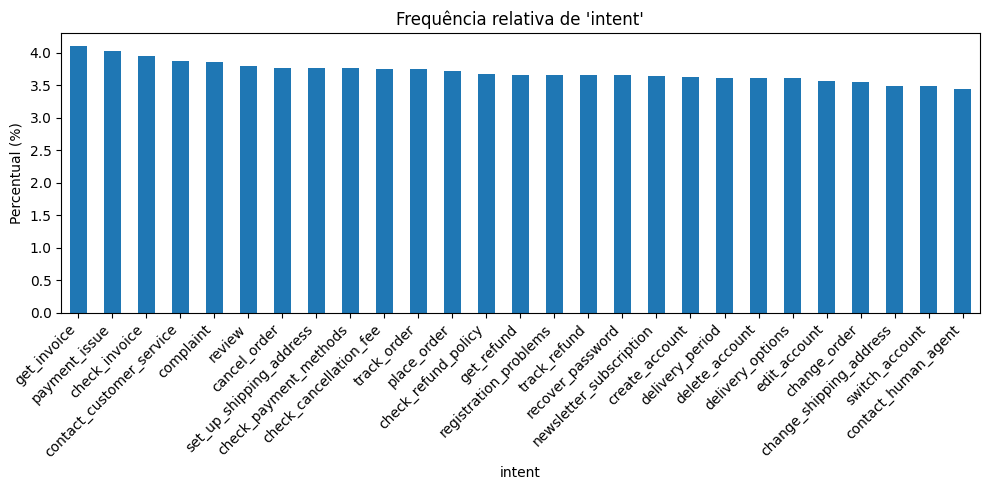



3. Categoria mais frequente:

Categoria mais frequente da variável 'intent':
Categoria: get_invoice
Quantidade: 268
Percentual: 4.10%


In [ ]:
# --------------------------------------------------------------------------------------------------
# Variável categórica: intent
# --------------------------------------------------------------------------------------------------

colunas_categoricas = ["intent"]


print_formatado("1. Quantidade de categorias:")
print("\nQuantidade de categorias únicas por variável:")
quantidade_categorias = df[colunas_categoricas].nunique()
print(quantidade_categorias)


print_formatado("2. Frequência absoluta e relativa:")
print("\nFrequência absoluta:")

for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts(dropna=False)
    print(f"\nVariável '{coluna}':")
    print(frequencia_absoluta)

    plt.figure(figsize=(10, 5))
    frequencia_absoluta.plot(kind="bar")
    plt.title(f"Frequência absoluta de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nFrequência relativa:")

for coluna in colunas_categoricas:

    frequencia_relativa = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    print(f"\nVariável '{coluna}' (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(10, 5))

    frequencia_relativa.plot(kind="bar")

    plt.title(f"Frequência relativa de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Percentual (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


print_formatado("3. Categoria mais frequente:")

for coluna in colunas_categoricas:

    categoria_mais_frequente = df[coluna].mode(dropna=False)[0]

    quantidade = (
        df[coluna]
        .value_counts(dropna=False)
        .iloc[0]
    )

    percentual = (
        df[coluna]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )

    print(f"\nCategoria mais frequente da variável '{coluna}':")
    print(f"Categoria: {categoria_mais_frequente}")
    print(f"Quantidade: {quantidade}")
    print(f"Percentual: {percentual:.2f}%")

# **Análise Multivariada**

In [ ]:
print_formatado("1. Associação entre variáveis do CountVectorizer x alvo:")
chi2_valores, p_valores = chi2(X_vetorizado, df["intent"])
resultado_associacao = pd.DataFrame({
    "palavra": vocabulario,
    "chi2": chi2_valores,
    "p_valor": p_valores
})
resultado_associacao = resultado_associacao.sort_values("chi2", ascending=False)
print("\nTeste Qui-quadrado:")
i = 0
for _, linha in resultado_associacao.iterrows():
    print(f"\n{linha['palavra']} x intent:")
    print(f"χ² = {linha['chi2']:.3f}")
    print(f"P-valor = {linha['p_valor']:.5f}")
    i += 1
    if i > 20:
      break

print_formatado("2. Associação entre variáveis do CountVectorizer:")
similaridade = cosine_similarity(X_vetorizado.T)
pares_similares = []
for i in range(len(vocabulario)):
    for j in range(i + 1, len(vocabulario)):
        pares_similares.append([
            vocabulario[i],
            vocabulario[j],
            similaridade[i, j]
        ])
resultado_similaridade = pd.DataFrame(
    pares_similares,
    columns=["palavra_1", "palavra_2", "similaridade"]
)
resultado_similaridade = resultado_similaridade.sort_values(
    "similaridade",
    ascending=False
)
print("\nPalavras com maior associação:")
print(resultado_similaridade.head(30))




1. Associação entre variáveis do CountVectorizer x alvo:

Teste Qui-quadrado:

newsletter x intent:
χ² = 6194.118
P-valor = 0.00000

address x intent:
χ² = 6009.287
P-valor = 0.00000

customer x intent:
χ² = 5439.428
P-valor = 0.00000

shipping x intent:
χ² = 5393.909
P-valor = 0.00000

options x intent:
χ² = 5267.810
P-valor = 0.00000

payment x intent:
χ² = 5052.400
P-valor = 0.00000

order x intent:
χ² = 5043.451
P-valor = 0.00000

delivery x intent:
χ² = 4870.066
P-valor = 0.00000

methods x intent:
χ² = 4629.480
P-valor = 0.00000

set x intent:
χ² = 4578.325
P-valor = 0.00000

refund x intent:
χ² = 4399.133
P-valor = 0.00000

buy x intent:
χ² = 4170.761
P-valor = 0.00000

registration x intent:
χ² = 4111.481
P-valor = 0.00000

agent x intent:
χ² = 4096.436
P-valor = 0.00000

account x intent:
χ² = 3848.800
P-valor = 0.00000

complaint x intent:
χ² = 3766.611
P-valor = 0.00000

review x intent:
χ² = 3728.347
P-valor = 0.00000

service x intent:
χ² = 3621.362
P-valor = 0.00000

mo

### **Observações de Análise Multivariada de Variáveis Textuais**

### 3. Analisar variáveis preditoras

* **`newsletter` (`χ² = 6194,118`) e `address` (`χ² = 6009,287`) apresentaram os maiores valores de Qui-quadrado, indicando forte associação com a variável-alvo `intent` e elevado potencial preditivo.**

* `customer` (`χ² = 5439,428`), `shipping` (`χ² = 5393,909`) e `options` (`χ² = 5267,810`) também apresentaram valores elevados de Qui-quadrado, indicando que sua ocorrência ajuda a diferenciar as categorias de `intent`.

* `payment` (`χ² = 5052,400`), `order` (`χ² = 5043,451`) e `delivery` (`χ² = 4870,066`) apresentaram elevada associação com o alvo e representam termos diretamente relacionados aos assuntos tratados nas solicitações dos clientes.

* Outros termos com elevado potencial preditivo incluem `methods` (`χ² = 4629,480`), `set` (`χ² = 4578,325`), `refund` (`χ² = 4399,133`), `buy` (`χ² = 4170,761`), `registration` (`χ² = 4111,481`), `agent` (`χ² = 4096,436`) e `account` (`χ² = 3848,800`).

* Os termos com maiores valores de Qui-quadrado são, em ordem decrescente: `newsletter`, `address`, `customer`, `shipping`, `options`, `payment`, `order`, `delivery`, `methods`, `set`, `refund`, `buy`, `registration`, `agent` e `account`.

* A maior parte dos termos com valores elevados de Qui-quadrado apresentou `p-valor < 0,05`, indicando associação estatisticamente significativa com `intent`.

* Termos relacionados diretamente aos diferentes tipos de atendimento, como `refund`, `payment`, `delivery`, `password`, `cancellation`, `invoice`, `registration` e `account`, apresentam potencial relevante para a classificação das intenções.

* Alguns termos apresentaram `p-valor > 0,05`, como `ya`, `say`, `card`, `try`, `possible`, `want` e `got`, não apresentando evidência estatisticamente significativa de associação com `intent` nesta análise.

* O vocabulário também contém diversos erros ortográficos ou termos pouco informativos, como `passowrd`, `accont`, `newslewtter`, `paymet` e `profle`. Esses termos tendem a ocorrer poucas vezes e podem gerar variáveis esparsas com baixo poder preditivo individual.

* Um valor elevado de Qui-quadrado indica maior associação entre a ocorrência do termo e a variável-alvo, mas não deve ser interpretado isoladamente como importância definitiva para o modelo. A frequência do termo e o desempenho do modelo também devem ser considerados durante a seleção de atributos.

* Os termos com maior associação devem inicialmente ser mantidos como variáveis preditoras, enquanto termos raros, não significativos ou resultantes de erros de digitação podem ser avaliados posteriormente para possível remoção durante o tratamento do vocabulário.

### 4. Analisar e tratar variáveis redundantes

* Foram identificados diversos pares de termos com `similaridade de cosseno = 1,000`, indicando que essas variáveis apresentaram exatamente o mesmo padrão de ocorrência nos documentos analisados.

* Entre os pares com similaridade máxima estão `look` x `quick`, `ihave` x `registered`, `free` x `phone`, `arent` x `wanted`, `arent` x `ones`, `according` x `entitled`, `copmlaint` x `unsatisfied`, `submitted` x `uupdatte` e `ones` x `wanted`.

* Similaridade igual a `1,000` indica sobreposição total no padrão de ocorrência das duas palavras dentro da matriz gerada pelo `CountVectorizer`. Esses pares devem ser investigados como possíveis variáveis redundantes.

* Entretanto, similaridade máxima não significa necessariamente que as palavras possuam o mesmo significado. Em alguns casos, o resultado pode ocorrer porque dois termos raros aparecem sempre nos mesmos poucos textos.

* `expect` e `soon` apresentaram similaridade muito elevada (`0,970`), enquanto `address` e `shipping` apresentaram similaridade de `0,930`. Esses pares possuem forte sobreposição no padrão de ocorrência e devem ser avaliados quanto à redundância.

* `ask` e `cases` apresentaram similaridade de `0,905`, também indicando elevada associação entre suas ocorrências.

* Outros pares com similaridade relativamente elevada foram `leave` x `review` (`0,857`), `feedback` x `submit` (`0,844`) e `breaking` x `contract` (`0,816`).

* Pares com similaridade abaixo de aproximadamente `0,80`, como `mistake` x `old`, `arrive` x `going` e `code` x `pin`, apresentam menor sobreposição e, em princípio, não representam os casos prioritários para tratamento de redundância.

* Os principais candidatos à investigação por redundância são, portanto, os pares com similaridade igual ou muito próxima de `1`, principalmente quando ambos os termos também apresentam frequências e comportamento semelhantes em relação ao alvo `intent`.

* Termos resultantes de erros de digitação, como `copmlaint` e `uupdatte`, devem receber atenção especial, pois podem representar versões incorretas de outras palavras do vocabulário e gerar variáveis desnecessárias.

* A remoção automática de uma palavra apenas por apresentar alta similaridade com outra não é recomendada. Antes da exclusão, deve-se verificar a frequência dos termos, seu significado e sua associação individual com `intent`.

* Caso duas variáveis apresentem alta similaridade entre si e comportamento semelhante em relação ao alvo, pode-se testar a remoção de uma delas para reduzir a dimensionalidade e a redundância da representação textual.

* A remoção definitiva deve ser confirmada comparando o desempenho do modelo com e sem as variáveis consideradas redundantes. Caso o desempenho permaneça semelhante, a variável removida pode ser considerada dispensável.



# **Identificação de Outliers e Anomalias**

### **Variáveis textuais**



1. Criar/identificar variáveis numéricas a partir da variável textual:
                                           utterance  qtd_palavras  \
0    would it be possible to cancel the order I made            10   
1                                   cancelling order             2   
2  I need assistance canceling the last order I h...            10   
3            problem with canceling the order I made             7   
4         I dont know how to cancel the order I made            10   

   tamanho_frase  qtd_termos_distintos  
0             47                     3  
1             16                     2  
2             54                     4  
3             39                     3  
4             42                     4  

Estatísticas:
       qtd_palavras  tamanho_frase  qtd_termos_distintos
count   6538.000000         6538.0           6538.000000
mean       8.315540      42.157541              3.775772
std        2.401941      10.558184              1.134876
min        1.0000

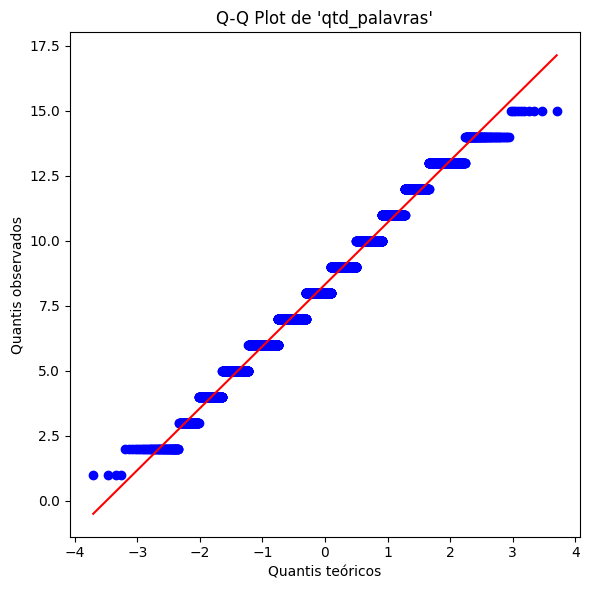

Assimetria             : 0.02732732134853504
Teste Shapiro-Wilk, p-valor:3.995268624468474e-24

Variável tamanho_frase:


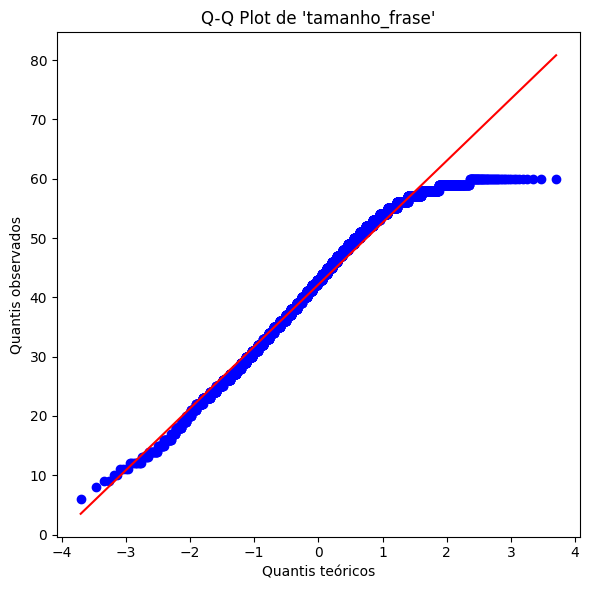

Assimetria             : -0.35135607815367087
Teste Shapiro-Wilk, p-valor:3.476788254866633e-28

Variável qtd_termos_distintos:


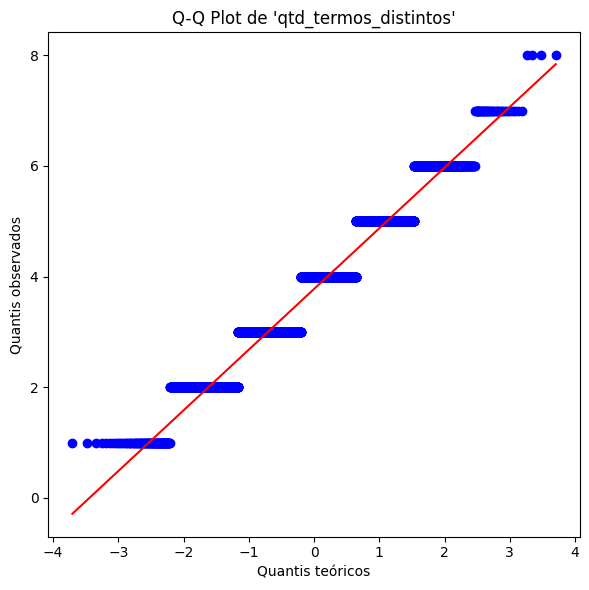

Assimetria             : 0.13434098445470408
Teste Shapiro-Wilk, p-valor:8.384716846904423e-43


In [ ]:
print_formatado("1. Criar/identificar variáveis numéricas a partir da variável textual:")
df["qtd_termos_distintos"] = ((X_vetorizado > 0).sum(axis=1).A1)
variavel_textual = 'utterance'
variaveis_numericas_by_textual = ["qtd_palavras", "tamanho_frase", "qtd_termos_distintos"]
print(df[["utterance"] + variaveis_numericas_by_textual].head())
print("\nEstatísticas:")
print(df[["qtd_palavras", "tamanho_frase", "qtd_termos_distintos"]].describe())

print_formatado("1.2. Selecionar método de identificação de outlier:")
print_formatado("1.2.1. Q-Q Plot, Assimetria, Shapiro-Wilk")

colunas_numericas = variaveis_numericas_by_textual
alpha = 0.05
tamanho_maximo_shapiro = 5000

variaveis_normais = []
variaveis_nao_normais = []
resultados_normalidade = {}

for coluna in colunas_numericas:

    print(f"\nVariável {coluna}:")
    dados = df[coluna].dropna()
    plt.figure(figsize=(6, 6))

    stats.probplot(
        dados,
        dist="norm",
        plot=plt
    )

    plt.title(f"Q-Q Plot de '{coluna}'")
    plt.xlabel("Quantis teóricos")
    plt.ylabel("Quantis observados")
    plt.tight_layout()
    plt.show()

    assimetria = stats.skew(dados, bias=False, nan_policy="omit")
    print(f"Assimetria             : {assimetria}")

    # ---------------------------------------------------------
    # Teste de Shapiro-Wilk
    # ---------------------------------------------------------
    # Para amostras grandes, são selecionadas no máximo
    # 5.000 observações, pois o teste é muito sensível.
    if len(dados) > tamanho_maximo_shapiro:
        dados_teste = dados.sample(
            n=tamanho_maximo_shapiro,
            random_state=1
        )
    else:
        dados_teste = dados

    estatistica_w, p_valor = stats.shapiro(dados_teste)
    print(f"Teste Shapiro-Wilk, p-valor:{p_valor}")


**Identificar Outliers com IQR ou Zscore**

In [ ]:

print_formatado("1.2. Identificar outliers com IQR ou ZScore")
colunas_iqr = ['tamanho_frase', 'qtd_termos_distintos']
colunas_zcore = ['qtd_palavras']

outliers_por_coluna = {}
indices_outliers = set()

for coluna in colunas_iqr:
    dados = df[coluna].dropna()

    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior))
    outliers_coluna = df.loc[mascara_outliers].copy()
    outliers_por_coluna[coluna] = outliers_coluna
    indices_outliers.update(outliers_coluna.index)

    print(f"\nVariável: {coluna}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {len(outliers_coluna)}")

    display(outliers_coluna[['utterance', coluna]])

max_desvio_padrao = 3

for coluna in colunas_zcore:
    dados = df[coluna].dropna()

    z_scores = zscore(dados)

    mascara_outliers = abs(z_scores) > max_desvio_padrao
    outliers_coluna = df.loc[dados.index[mascara_outliers]].copy()

    outliers_por_coluna[coluna] = outliers_coluna
    indices_outliers.update(outliers_coluna.index)

    print(f"\nVariável: {coluna}")
    print(f"Média: {dados.mean():.2f}")
    print(f"Desvio padrão: {dados.std(ddof=0):.2f}")
    print(f"Quantidade de outliers: {len(outliers_coluna)}")

    display(outliers_coluna[['utterance', coluna]])


print_formatado("3. Identificação de termos raros:")
frequencia_documentos = ((X_vetorizado > 0).sum(axis=0).A1)
df_termos = pd.DataFrame({"palavra": vocabulario,"qtd_documentos": frequencia_documentos})
df_termos = df_termos.sort_values("qtd_documentos",ascending=True)
print("Termos menos frequentes:")
display(df_termos.head(30))



1.2. Identificar outliers com IQR ou ZScore

Variável: tamanho_frase
Q1: 35.00
Q3: 51.00
IQR: 16.00
Limite inferior: 11.00
Limite superior: 75.00
Quantidade de outliers: 6


,utterance,tamanho_frase
1749,complaint,9
2630,register,8
3987,get refund,10
4669,make order,10
5335,review,6
6129,order ETA,9



Variável: qtd_termos_distintos
Q1: 3.00
Q3: 5.00
IQR: 2.00
Limite inferior: 0.00
Limite superior: 8.00
Quantidade de outliers: 0


,utterance,qtd_termos_distintos



Variável: qtd_palavras
Média: 8.32
Desvio padrão: 2.40
Quantidade de outliers: 4


,utterance,qtd_palavras
1749,complaint,1
2451,registering,1
2630,register,1
5335,review,1




3. Identificação de termos raros:
Termos menos frequentes:


,palavra,qtd_documentos
555,youur,1
549,witth,1
2,abuot,1
3,accdss,1
547,wit,1
544,whyat,1
529,uswer,1
530,utell,1
531,uupdatte,1
39,apyment,1


### **Observações Identificação de Outliers e Anomalias**

### 1.2. Identificar outliers com IQR ou ZScore;

* Nenhum possível outlier será removido:

  * `qtd_palavras`: decisão é manter os outliers identificados pelo IQR. Foram identificados 73 outliers, considerando valores abaixo de 2,5 ou acima de 14,5 palavras. Como a quantidade de palavras é inteira, mensagens com até 2 palavras ou com 15 palavras são consideradas outliers. Os exemplos identificados, como `cancel order`, `track order`, `refund status` e `tracking refund`, são mensagens curtas, porém válidas dentro do contexto de atendimento ao cliente. Logo, não há evidência de que esses registros representem erros.
  * `tamanho_frase`: decisão é manter os 6 outliers identificados pelo ZScore. As mensagens identificadas possuem tamanho bastante inferior à média de 42,16 caracteres, como `complaint`, `register`, `review` e `order ETA`. Apesar de serem frases muito curtas, elas representam solicitações possíveis de usuários e não caracterizam necessariamente dados incorretos.
  * `qtd_termos_distintos`: decisão é manter os 4 outliers identificados pelo ZScore. Os registros possuem 8 termos distintos, enquanto a média do dataset é de 3,78 termos distintos. As mensagens identificadas são mais complexas e possuem maior diversidade de termos, porém continuam sendo textos válidos dentro do domínio de atendimento ao cliente.

### 1.3. Identificar termos raros;

* Foram identificados diversos termos presentes em apenas um documento:

  * Parte desses termos apresenta indícios de erros de digitação, como `youur`, `witth`, `abuot`, `accdss`, `uupdatte`, `apyment`, `assisatance`, `newsleter`, `acconut`, `accouint` e `accounmt`.
  * Entretanto, também existem termos raros aparentemente válidos, como `according` e `word`. Logo, uma baixa frequência não significa necessariamente que o termo seja incorreto.
  * Decisão é não remover automaticamente os termos raros ou os registros em que aparecem. Erros de digitação podem ocorrer naturalmente em mensagens de atendimento ao cliente e fazem parte das características do domínio. Caso necessário, a correção ou normalização desses termos poderá ser considerada posteriormente durante avaliação do modelo.


# **Teste de hipótese**

## **Identificação de hipótese**

### Hipótese nula (H₀)

A quantidade de palavras das `utterances` não apresenta diferença estatisticamente significativa entre os dois `intents` analisados.

### Hipótese alternativa (H₁)

A quantidade de palavras das `utterances` apresenta diferença estatisticamente significativa entre os dois `intents` analisados.

### Nível de significância

Será adotado um nível de significância de **5% (α = 0,05)**.

- Se `p < 0,05`,  H₀ rejeitada.
- Se `p >= 0,05`, H₀ não rejeitada.

In [ ]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

intent1 = "cancel_order"
intent2 = "delete_account"

grupo1 = df[df["intent"] == intent1]["qtd_palavras"]
grupo2 = df[df["intent"] == intent2]["qtd_palavras"]

u, p_valor = mannwhitneyu(grupo1, grupo2, alternative="two-sided")

print_formatado(f"Teste Mann-Whitney para {intent1} e {intent2} e qtd_palavras:")
print(f"{intent1}")
print(f"Quantidade de exemplos:", len(grupo1))
print(f"Mediana:", grupo1.median())
print(f"\nQuantidade de exemplos {intent2}:", len(grupo2))
print(f"Mediana {intent2}:", grupo2.median())
print("\nEstatística U:", u)
print("p-valor:", p_valor)




intent1 = "cancel_order"
intent2 = "delete_account"
grupo1 = df[df["intent"] == intent1]["qtd_palavras"]
grupo2 = df[df["intent"] == intent2]["qtd_palavras"]
estatistica, p_valor = ttest_ind(grupo1, grupo2,equal_var=False)

print_formatado(f"Teste t de Welch para {intent1} e {intent2} e qtd_palavras:")
print(f"{intent1}:")
print("Quantidade de exemplos:", len(grupo1))
print("Média:", grupo1.mean())
print()
print(f"{intent2}:")
print("Quantidade de exemplos:", len(grupo2))
print("Média:", grupo2.mean())
print()
print("Estatística t:", estatistica)
print("p-valor:", p_valor)




Teste Mann-Whitney para cancel_order e delete_account e qtd_palavras:
cancel_order
Quantidade de exemplos: 246
Mediana: 8.0

Quantidade de exemplos delete_account: 236
Mediana delete_account: 8.0

Estatística U: 29786.0
p-valor: 0.6165799526483032


Teste t de Welch para cancel_order e delete_account e qtd_palavras:
cancel_order:
Quantidade de exemplos: 246
Média: 8.036585365853659

delete_account:
Quantidade de exemplos: 236
Média: 8.01271186440678

Estatística t: 0.1204332355255004
p-valor: 0.9041907335391229


# **Definição de modelo**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Transformar intent em valores numéricos
encoder = LabelEncoder()
df["intent_num"] = encoder.fit_transform(df["intent"])
print(df)

# Separar atributos e alvo
X = df[["tamanho_frase"]]
# y = df['intent_num']
y = df["qtd_palavras"]
print(df['qtd_palavras'])

# Separar dados de treinamento e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Realizar previsões
previstos = modelo.predict(X_teste)

# Calcular métricas
r2 = r2_score(y_teste, previstos)
mse = mean_squared_error(y_teste, previstos)
rmse = mse ** 0.5

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

# Validação cruzada
scores = cross_val_score(modelo, X, y, cv=5, scoring="r2")

previstos_cv = cross_val_predict(modelo, X, y, cv=5)
print("previstos_cv: ", previstos_cv)

print("R² de cada divisão:", scores)
print("R² médio:", scores.mean())

                                              utterance        intent  \
0       would it be possible to cancel the order I made  cancel_order   
1                                      cancelling order  cancel_order   
2     I need assistance canceling the last order I h...  cancel_order   
3               problem with canceling the order I made  cancel_order   
4            I dont know how to cancel the order I made  cancel_order   
...                                                 ...           ...   
6533  I do not know what I have to do to track the r...  track_refund   
6534                                check refund status  track_refund   
6535                    help me check the refund status  track_refund   
6536  how can I check if there is any updates on my ...  track_refund   
6537  how do I check if there is anything wrong with...  track_refund   

      qtd_palavras  tamanho_frase  qtd_termos_distintos  intent_num  
0               10             47                    

## **Observações de Definição do Modelo**

### 1. Desempenho no conjunto de teste

* O modelo de Regressão Linear apresentou **R² = 0,663**, indicando que aproximadamente **66,3% da variação de `qtd_palavras` é explicada por `tamanho_frase`**.

* O **MSE foi de 1,890**, representando a média dos erros quadráticos das previsões.

* O **RMSE foi de 1,375 palavras**, indicando que o erro típico das previsões é de aproximadamente **1,4 palavra**.

### 2. Validação cruzada

* Os valores de R² obtidos nas cinco divisões foram:

  * `0,661`
  * `0,715`
  * `0,725`
  * `0,513`
  * `0,734`

* O **R² médio da validação cruzada foi de 0,670**, valor próximo ao R² obtido no conjunto de teste (`0,663`).

  * Essa proximidade indica que o desempenho observado na divisão treino/teste é compatível com o desempenho médio obtido em diferentes divisões do dataset.

* Houve alguma variação entre as divisões, com R² entre aproximadamente **0,51 e 0,73**.

  * Portanto, o desempenho do modelo apresenta certa dependência dos exemplos utilizados em cada divisão, embora a maior parte dos resultados permaneça próxima do desempenho médio.

* De forma geral, `tamanho_frase` apresenta capacidade relevante para explicar `qtd_palavras`, mas aproximadamente **um terço da variabilidade do target permanece não explicado pelo modelo**.


# **Análise residual**


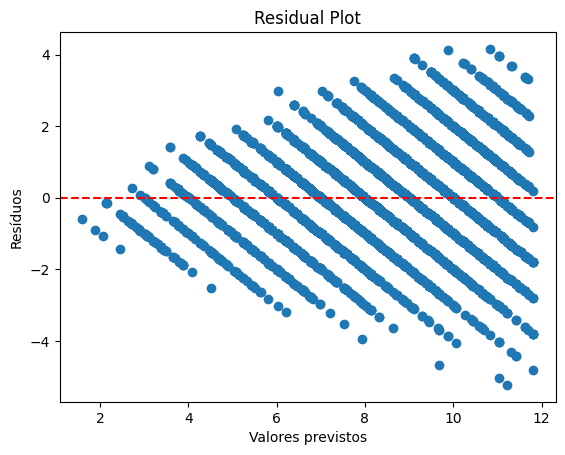

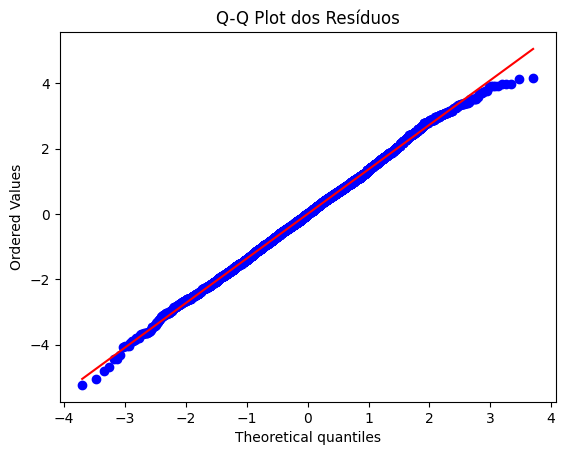

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

# Obter previsões usando validação cruzada
previstos_cv = cross_val_predict(modelo, X, y, cv=5)

# Calcular resíduos
residuos = y - previstos_cv

# Residual plot
plt.scatter(previstos_cv, residuos)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Residual Plot")
plt.show()

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Q-Q Plot dos Resíduos")
plt.show()

## **Observações de Análise Residual**

### 1. Residual Plot

* Os resíduos estão distribuídos em torno de zero, sem tendência clara de superestimar ou subestimar os valores.

* A dispersão dos resíduos aumenta conforme os valores previstos crescem.

  * Esse comportamento indica **heterocedasticidade**, ou seja, a variância dos erros não é constante.

* As faixas diagonais aparecem porque `qtd_palavras` é uma variável discreta, formada por valores inteiros.

### 2. Q-Q Plot

* A maior parte dos pontos permanece próxima da linha de referência.

  * Isso indica que os resíduos apresentam distribuição **aproximadamente normal**.

* Existem pequenos desvios nas extremidades, mostrando que a normalidade não é perfeita nas caudas.

### 3. Conclusão

* O modelo apresenta resíduos aproximadamente normais, mas há evidência de heterocedasticidade.

* Isso significa que o modelo representa razoavelmente a relação entre `tamanho_frase` e `qtd_palavras`, porém os erros tendem a ficar mais dispersos para valores previstos maiores.

* Para fins preditivos, o modelo continua sendo útil, mas sua precisão não é uniforme em toda a faixa de valores.